# 🤖 학생 건강상태 분류 — 모델링 및 모델 선택

**EDA와 파생변수 검증 결과를 바탕으로 모델을 비교하고 최종 모델을 선정하는 단계**

## 노트북 목표

이 노트북에서는 전처리된 데이터를 활용해 여러 분류 모델의 성능을 비교하고, 성능과 학습 시간을 함께 고려하여 최종 모델을 선택한다.

최종적으로는 선택한 모델을 튜닝한 뒤 전체 학습 데이터로 학습하고, `submission.csv` 파일을 생성한다.

## 진행 내용

1. **변수 선택**
   - 이전 EDA와 Mutual Information(MI) 결과를 참고하여 타깃 예측과 관련성이 낮은 변수를 확인한다.
   - 성능에 도움이 되지 않거나 의미가 불명확한 변수는 제외하고, 최종 모델링에 사용할 변수를 정리한다.
   - 변수 제거 전후의 성능도 비교하여 실제로 제외해도 되는지 확인한다.

2. **범주형 변수 인코딩**
   - 순서가 있는 범주형 변수는 순서를 반영할 수 있도록 서열 인코딩(`_ord`)을 적용한다.
   - 순서가 없는 명목형 변수는 One-Hot Encoding을 적용한다.
   - 변수의 특성에 따라 인코딩 방식을 다르게 적용하여 모델이 정보를 더 잘 활용할 수 있도록 한다.

3. **모델 비교**
   - 기본 모델부터 부스팅 계열 모델까지 총 12개 모델을 비교한다.
   - sklearn 기반 모델과 XGBoost, LightGBM, CatBoost를 함께 사용한다.
   - 모든 모델은 동일한 Train/Validation 분할 조건에서 평가한다.
   - 평가 지표는 클래스 불균형을 고려해 Balanced Accuracy를 사용한다.
   - 각 모델의 학습 및 예측 시간도 함께 측정한다.

4. **성능과 실행시간 비교**
   - 모델별 Balanced Accuracy와 실행시간을 표로 정리한다.
   - 성능 비교 그래프와 실행시간 대비 성능 산점도를 생성한다.
   - 단순히 점수가 가장 높은 모델만 선택하지 않고, 성능 차이와 실행시간 차이를 함께 확인한다.

5. **최종 모델 선택 및 튜닝**
   - Validation Balanced Accuracy, 교차검증 결과, 실행시간을 종합적으로 고려하여 최종 후보 모델을 선정한다.
   - 선택한 모델에 대해 주요 하이퍼파라미터를 조정하고 성능 변화를 확인한다.
   - 튜닝 결과가 기존 모델보다 개선되지 않으면, 더 단순하고 안정적인 설정을 선택한다.

6. **전체 데이터 학습 및 제출 파일 생성**
   - 최종 모델을 전체 Train 데이터로 다시 학습한다.
   - Test 데이터에 대해 예측을 수행한다.
   - Kaggle 제출 형식에 맞춰 `submission.csv` 파일을 생성한다.

## 모델 선택 기준

최종 모델은 아래 기준을 종합하여 선택한다.

- Validation Balanced Accuracy가 높은가
- 교차검증 결과가 안정적인가
- 특정 클래스만 잘 맞히지 않고 클래스별 Recall이 균형적인가
- 학습 시간이 과도하게 길지 않은가
- 튜닝 후에도 재현 가능한 성능을 보이는가

> 높은 점수도 중요하지만, 데이터 분할이 바뀌었을 때 성능이 크게 흔들리지 않는 모델을 우선적으로 선택한다.

## 저장 결과물

발표 자료와 팀 공유를 위해 아래 결과물을 저장한다.

- 모델별 성능 및 실행시간 비교표 (`CSV`)
- 상위 모델 교차검증 결과표 (`CSV`)
- 모델별 Balanced Accuracy 비교 그래프 (`PNG`)
- 실행시간 대비 Balanced Accuracy 산점도 (`PNG`)
- 최종 모델의 Confusion Matrix (`PNG`)
- 변수 중요도 그래프 (`PNG`)
- Kaggle 제출 파일 (`submission.csv`)

## 0. 라이브러리 설치 & import

XGBoost / LightGBM / CatBoost를 모두 설치


In [1]:
!pip install -q lightgbm xgboost catboost
print('설치 완료')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00
설치 완료


In [2]:
# (선택) 한글 폰트
import os
try:
    import matplotlib.font_manager as fm
    if not any('Nanum' in f.name for f in fm.fontManager.ttflist):
        os.system('apt-get -qq -y install fonts-nanum > /dev/null 2>&1')
        for fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
            fm.fontManager.addfont(fp)
except Exception as e:
    print('폰트 스킵:', e)


In [3]:
import time, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.base import clone

try:
    import matplotlib.font_manager as fm
    if any('Nanum' in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = 'NanumGothic'
except Exception: pass
plt.rcParams['axes.unicode_minus'] = False
RS = 42; np.random.seed(RS)
pd.set_option('display.max_columns', 60)
print('준비 완료 ✅')


준비 완료 ✅


## 1. 데이터 로드 + 파생변수 생성

파생변수 함수는 EDA 노트북과 동일 (모든 파생을 일단 만든 뒤, 다음 단계에서 정예만 선택).


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/'
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
TARGET, ID = 'health_condition', 'id'
numeric_features = ['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']
categorical_features = ['diet_type','stress_level','sleep_quality','physical_activity_level','smoking_alcohol','gender']
feature_cols = numeric_features + categorical_features

HR_HI=train['heart_rate'].quantile(0.75); STEP_LO=train['step_count'].quantile(0.25); WATER_LO=train['water_intake'].quantile(0.25)
ord_maps={'stress_level':{'low':0,'medium':1,'high':2},'sleep_quality':{'poor':0,'average':1,'good':2},
 'physical_activity_level':{'sedentary':0,'moderate':1,'active':2},'smoking_alcohol':{'no':0,'occasional':1,'yes':2}}
def make_features(df):
    X=df.copy()
    for col,m in ord_maps.items(): X[col+'_ord']=X[col].map(m)
    X['sleep_debt']=(7-X['sleep_duration']).clip(lower=0); X['sleep_excess']=(X['sleep_duration']-9).clip(lower=0)
    X['sleep_ideal']=X['sleep_duration'].between(7,9).astype('float'); X.loc[X['sleep_duration'].isna(),'sleep_ideal']=np.nan
    X['bmi_cat']=pd.cut(X['bmi'],bins=[-np.inf,18.5,25,30,np.inf],labels=[0,1,2,3]).astype('float')
    X['bmi_abnormal']=(~X['bmi'].between(18.5,25)).astype('float'); X.loc[X['bmi'].isna(),'bmi_abnormal']=np.nan
    X['hr_high']=(X['heart_rate']>HR_HI).astype('float'); X.loc[X['heart_rate'].isna(),'hr_high']=np.nan
    X['steps_per_ex_min']=X['step_count']/(X['exercise_duration']+1); X['cal_per_step']=X['calorie_expenditure']/(X['step_count']+1)
    X['low_activity']=(X['step_count']<STEP_LO).astype('float'); X.loc[X['step_count'].isna(),'low_activity']=np.nan
    X['low_water']=(X['water_intake']<WATER_LO).astype('float'); X.loc[X['water_intake'].isna(),'low_water']=np.nan
    risk=pd.DataFrame(index=X.index)
    risk['r_sleep']=(X['sleep_duration']<6).astype(float); risk['r_stress']=(X['stress_level']=='high').astype(float)
    risk['r_sleepq']=(X['sleep_quality']=='poor').astype(float); risk['r_sed']=(X['physical_activity_level']=='sedentary').astype(float)
    risk['r_lowstep']=(X['step_count']<STEP_LO).astype(float); risk['r_smoke']=(X['smoking_alcohol']=='yes').astype(float)
    risk['r_bmi']=(~X['bmi'].between(18.5,25)).astype(float)
    X['lifestyle_risk_score']=risk.sum(axis=1); X['n_missing']=df[feature_cols].isnull().sum(axis=1)
    for c in feature_cols: X[c+'_isna']=df[c].isnull().astype('int8')
    return X
train_fe=make_features(train); test_fe=make_features(test)
print('train_fe', train_fe.shape)


train_fe (690088, 44)


## 2. ⭐ 변수 가지치기

앞선 EDA와 파생변수 검증 결과를 바탕으로, 모델링에 사용할 변수를 정리한다.

모든 변수를 그대로 사용하는 것보다 타깃과 관련성이 낮은 변수를 줄이는 것이 모델을 단순하게 만들고, 불필요한 노이즈를 줄이는 데 도움이 될 수 있다.

### 유지한 변수

Mutual Information(MI) 결과에서 상대적으로 타깃과 관련성이 높게 나타난 변수는 유지한다.

- `lifestyle_risk_score`
- 순서형 변수의 서열 인코딩 변수(`*_ord`)
- `sleep_debt`
- `sleep_ideal`
- `bmi_cat`
- `cal_per_step`

### 제거한 변수

MI 값이 거의 0에 가까웠거나, 모델 성능에 뚜렷한 도움이 확인되지 않은 변수는 제외한다.

- 결측 여부 변수(`*_isna`)
- `n_missing`
- `low_water`
- `hr_high`
- `sleep_excess`
- `bmi_abnormal`

이 변수들은 정보가 전혀 없다고 단정하기보다는, 이번 모델링 데이터와 검증 조건에서는 추가적인 예측력을 거의 보여주지 않아 우선 제외했다.

## 범주형 변수 인코딩 방법

범주형 변수는 값에 순서가 있는지에 따라 인코딩 방식을 다르게 적용했다.

| 종류 | 변수 | 인코딩 방법 | 적용 이유 |
|---|---|---|---|
| 순서형 | `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol` | 서열 인코딩(`*_ord`) | `low < medium < high`처럼 값의 순서가 의미를 가지므로 숫자로 변환해 순서 정보를 반영한다. |
| 명목형 | `diet_type`, `gender` | One-Hot Encoding | 범주 간 순서가 없기 때문에 숫자를 임의로 부여하면 잘못된 순서 관계가 생길 수 있다. |

순서형 변수는 예를 들어 `low`, `medium`, `high`를 각각 0, 1, 2와 같이 변환한다. 이렇게 하면 트리 모델이 특정 수준 이상에서 위험도가 달라지는 패턴을 쉽게 학습할 수 있다.

반면 `diet_type`이나 `gender`처럼 범주 간 우열이나 순서가 없는 변수는 One-Hot Encoding을 적용한다. 숫자를 직접 부여하면 모델이 범주 사이에 실제로 존재하지 않는 순서를 학습할 수 있기 때문이다.

따라서 이번 분석에서는 다음 원칙을 적용했다.

> 순서가 있는 변수는 서열 인코딩을 사용하고, 순서가 없는 변수는 One-Hot Encoding을 사용한다.

순서형 변수에 One-Hot Encoding과 서열 인코딩을 동시에 적용하면 같은 정보를 중복해서 제공할 수 있으므로, 최종 모델에서는 서열 인코딩 변수만 사용했다.

In [6]:
# --- 정예 변수 세트 ---
num_final = numeric_features + [
    'lifestyle_risk_score','sleep_debt','sleep_ideal','bmi_cat',
    'cal_per_step','steps_per_ex_min','low_activity',
    'stress_level_ord','sleep_quality_ord','physical_activity_level_ord','smoking_alcohol_ord',
]
cat_final = ['diet_type','gender']   # 명목형만 OneHot

dropped = ['sleep_excess','bmi_abnormal','hr_high','low_water','n_missing'] + \
          [c+'_isna' for c in feature_cols] + \
          ['stress_level','sleep_quality','physical_activity_level','smoking_alcohol']  # 순서형 원본은 _ord로 대체
print(f'유지: 수치/서열 {len(num_final)}개 + 명목 OneHot {len(cat_final)}개')
print(f'제거: {len(dropped)}개 (죽은 변수 + 순서형 원본 중복)')
print('\n제거 목록:', dropped)


유지: 수치/서열 18개 + 명목 OneHot 2개
제거: 22개 (죽은 변수 + 순서형 원본 중복)

제거 목록: ['sleep_excess', 'bmi_abnormal', 'hr_high', 'low_water', 'n_missing', 'sleep_duration_isna', 'heart_rate_isna', 'bmi_isna', 'calorie_expenditure_isna', 'step_count_isna', 'exercise_duration_isna', 'water_intake_isna', 'diet_type_isna', 'stress_level_isna', 'sleep_quality_isna', 'physical_activity_level_isna', 'smoking_alcohol_isna', 'gender_isna', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol']


## 3. 전처리 아키텍처 (Pipeline)

- 수치/서열 → 중앙값 대치 + 표준화
- 명목형 → 최빈값 대치 + OneHot
- 이 `preprocessor`를 12개 모델 앞에 동일하게 붙임 = "머신러닝 아키텍처" 요건


In [7]:
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                             ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', numeric_pipe, num_final), ('cat', categorical_pipe, cat_final)])
print('preprocessor 구성 완료 ✅ | 입력 컬럼:', len(num_final)+len(cat_final))


preprocessor 구성 완료 ✅ | 입력 컬럼: 20


## 4. 모델 12종 + "왜 이 모델을 넣었는가"

발표에서 "아무거나 10개"가 아니라 **의도를 갖고 계열별로 배치**했다고 말할 수 있게 정리했습니다.

| # | 모델 | 계열 | 넣은 이유 / 기대 |
|---|---|---|---|
| 1 | LogisticRegression | 선형 | 해석 쉬운 기준선. 파생변수 효과가 선형모델에서 큰지 확인 |
| 2 | RidgeClassifier | 선형+정규화 | 다중공선성에 강한 선형 |
| 3 | LinearSVC | 선형(마진) | 마진 기반 관점의 선형 |
| 4 | KNN | 거리기반 | 국소 패턴 비선형 기준선 |
| 5 | GaussianNB | 확률기반 | 초고속 확률 기준선 |
| 6 | DecisionTree | 트리 | 앙상블 전 단일 트리 기준 |
| 7 | RandomForest | 배깅 | 분산↓, 안정적 앙상블 |
| 8 | ExtraTrees | 배깅(더 랜덤) | RF 변형 비교 |
| 9 | HistGradientBoosting | 부스팅(sklearn) | 빠르고 강한 부스팅 |
| 10 | **LightGBM** | 부스팅(leaf-wise) | 대용량에 빠름, 캐글 강자 |
| 11 | **XGBoost** | 부스팅(level-wise) | 캐글 표준, 규제 강함 |
| 12 | **CatBoost** | 부스팅(범주형 특화) | 순서형/범주형에 강함 |

> **불균형 대응**: 지원 모델은 `class_weight='balanced'`(CatBoost는 `auto_class_weights`, XGBoost는 아래 래퍼로 sample_weight 자동 적용). KNN/GaussianNB는 미지원 → 기준선 역할.


In [8]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RS),
    'RidgeClassifier':    RidgeClassifier(class_weight='balanced', random_state=RS),
    'LinearSVC':          LinearSVC(class_weight='balanced', random_state=RS),
    'KNN':                KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
    'GaussianNB':         GaussianNB(),
    'DecisionTree':       DecisionTreeClassifier(class_weight='balanced', max_depth=12, random_state=RS),
    'RandomForest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=RS),
    'ExtraTrees':         ExtraTreesClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=RS),
    'HistGradientBoosting': HistGradientBoostingClassifier(class_weight='balanced', max_iter=300, random_state=RS),
}
# --- 부스팅 3종 (설치 실패 시 자동 제외) ---
try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                                        class_weight='balanced', random_state=RS, n_jobs=-1, verbose=-1)
except Exception as e: print('LightGBM 제외:', e)
try:
    from xgboost import XGBClassifier
    from sklearn.utils.class_weight import compute_sample_weight
    class BalancedXGB(XGBClassifier):           # 불균형 대응: fit 때 sample_weight 자동 주입
        def fit(self, X, y, **kw):
            return super().fit(X, y, sample_weight=compute_sample_weight('balanced', y), **kw)
    models['XGBoost'] = BalancedXGB(n_estimators=300, learning_rate=0.1, max_depth=6, tree_method='hist',
                                    random_state=RS, n_jobs=-1, verbosity=0, eval_metric='mlogloss')
except Exception as e: print('XGBoost 제외:', e)
try:
    from catboost import CatBoostClassifier
    models['CatBoost'] = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                                            auto_class_weights='Balanced', random_state=RS, verbose=0)
except Exception as e: print('CatBoost 제외:', e)

print(f'\n총 {len(models)}개 모델:', list(models.keys()))



총 12개 모델: ['LogisticRegression', 'RidgeClassifier', 'LinearSVC', 'KNN', 'GaussianNB', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'LightGBM', 'XGBoost', 'CatBoost']


## 5. 비교용 층화 샘플 (10만 건)

전체 69만으로 12개를 돌리면 매우 오래 걸릴 것이다. **10만 건 층화 샘플**로 상대 비교하고, 최종 모델만 전체로 재학습.
타깃은 XGBoost 호환을 위해 **정수 라벨(LabelEncoder)** 로 변환 (모든 지표는 동일하게 계산됨).


In [9]:
COMPARE_SAMPLE = 100000
samp = train_fe.groupby(TARGET, group_keys=False).apply(
    lambda s: s.sample(min(len(s), int(COMPARE_SAMPLE*len(s)/len(train_fe))+1), random_state=RS))
X_samp = samp[num_final + cat_final]
le = LabelEncoder().fit(train_fe[TARGET])         # fit / at-risk / unhealthy -> 0/1/2
y_samp = le.transform(samp[TARGET])
print('비교 샘플:', X_samp.shape, '| 클래스:', dict(zip(le.classes_, np.bincount(y_samp))))


비교 샘플: (100001, 20) | 클래스: {'at-risk': np.int64(85868), 'fit': np.int64(5768), 'unhealthy': np.int64(8365)}


## 6. ⭐ 12개 모델 비교

앞에서 정리한 변수와 인코딩 방식을 동일하게 적용한 뒤, 총 12개 분류 모델의 성능을 비교한다.

모델마다 학습 속도와 예측 성능에 차이가 있기 때문에, Balanced Accuracy만 확인하지 않고 학습 시간도 함께 기록한다.

### 평가 방법

- 교차검증: 3-Fold Cross-Validation
- 주요 평가 지표: `balanced_accuracy`
- 보조 평가 지표: `f1_macro`
- 실행 환경: CPU
- CV 실행 방식: `n_jobs=1` 순차 실행

`cross_validate`를 사용하면 각 Fold의 `fit_time`과 `score_time`을 확인할 수 있다. 이번 비교에서는 여러 모델의 시간을 같은 조건에서 측정하기 위해 CV를 순차적으로 실행한다.

모델별 결과에는 다음 항목을 기록한다.

- 평균 Balanced Accuracy
- Balanced Accuracy 표준편차
- 평균 Macro F1
- 평균 학습 시간(`fit_time`)
- 평균 예측 시간(`score_time`)

### 참고 사항

XGBoost, LightGBM, CatBoost와 같은 부스팅 모델은 다른 모델보다 학습 시간이 오래 걸릴 수 있다. 따라서 전체 비교에는 수 분에서 십수 분 정도가 걸릴 수 있다.

실행 시간이 오래 걸리더라도 모든 모델을 동일한 데이터 분할과 평가 방식으로 비교하여 결과의 공정성을 유지한다.

> 이번 비교에서는 점수가 높은 모델뿐만 아니라, 성능이 안정적인지와 학습 시간이 지나치게 오래 걸리지 않는지도 함께 확인한다.

In [10]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RS)
scoring = ['balanced_accuracy', 'f1_macro']
rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    try:
        r = cross_validate(pipe, X_samp, y_samp, cv=cv, scoring=scoring, n_jobs=1, error_score='raise')
        rows.append({'model':name,
                     'balanced_acc':r['test_balanced_accuracy'].mean(),
                     'std':r['test_balanced_accuracy'].std(),
                     'f1_macro':r['test_f1_macro'].mean(),
                     'fit_time(s)':r['fit_time'].mean()})
        print(f'✔ {name:22s} bal_acc={rows[-1]["balanced_acc"]:.4f}  ±{rows[-1]["std"]:.4f}  time={rows[-1]["fit_time(s)"]:.1f}s')
    except Exception as e:
        print(f'✘ {name:22s} 실패: {str(e)[:70]}')

result = pd.DataFrame(rows).sort_values('balanced_acc', ascending=False).reset_index(drop=True)
display(result.round(4))

# 발표용 저장
import os
RESULT_DIR = DATA_PATH + 'results/'; os.makedirs(RESULT_DIR, exist_ok=True)
result.round(4).to_csv(RESULT_DIR + 'model_comparison.csv', index=False)
print('\n표 저장:', RESULT_DIR + 'model_comparison.csv')


✔ LogisticRegression     bal_acc=0.8672  ±0.0004  time=2.7s
✔ RidgeClassifier        bal_acc=0.8166  ±0.0018  time=0.3s
✔ LinearSVC              bal_acc=0.8284  ±0.0038  time=0.9s
✔ KNN                    bal_acc=0.7869  ±0.0026  time=0.2s
✔ GaussianNB             bal_acc=0.8405  ±0.0008  time=0.3s
✔ DecisionTree           bal_acc=0.8885  ±0.0039  time=1.7s
✔ RandomForest           bal_acc=0.8386  ±0.0013  time=29.3s
✔ ExtraTrees             bal_acc=0.8364  ±0.0018  time=12.6s
✔ HistGradientBoosting   bal_acc=0.9057  ±0.0015  time=2.9s
✔ LightGBM               bal_acc=0.8831  ±0.0022  time=13.4s
✔ XGBoost                bal_acc=0.8911  ±0.0013  time=11.7s
✔ CatBoost               bal_acc=0.9051  ±0.0021  time=15.0s


,model,balanced_acc,std,f1_macro,fit_time(s)
0,HistGradientBoosting,0.9057,0.0015,0.7756,2.9289
1,CatBoost,0.9051,0.0021,0.7702,15.0050
2,XGBoost,0.8911,0.0013,0.8425,11.6602
3,DecisionTree,0.8885,0.0039,0.7475,1.6628
4,LightGBM,0.8831,0.0022,0.8648,13.4334
5,LogisticRegression,0.8672,0.0004,0.6539,2.6746
6,GaussianNB,0.8405,0.0008,0.6094,0.3132
7,RandomForest,0.8386,0.0013,0.8940,29.2735
8,ExtraTrees,0.8364,0.0018,0.8929,12.5546
9,LinearSVC,0.8284,0.0038,0.8076,0.8555



표 저장: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/results/model_comparison.csv


## 7. 시간 vs 성능 산점도 (요건)

**왼쪽 위 = 빠르면서 정확(가성비 최고)**, 오른쪽 위 = 느리지만 정확.


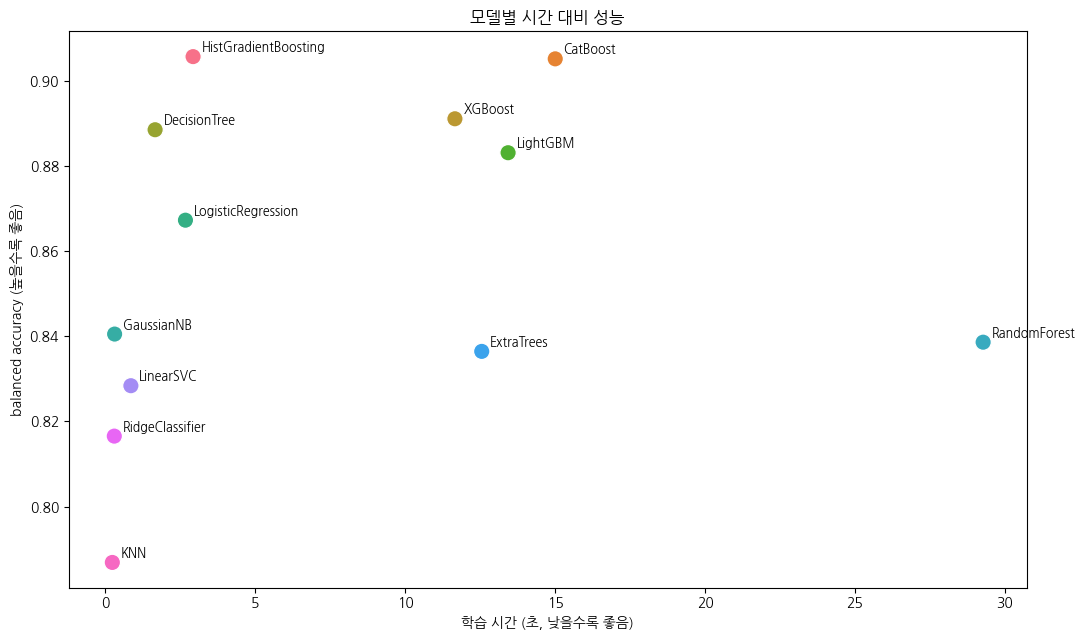

그래프 저장: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/results/model_comparison_scatter.png


In [11]:
plt.figure(figsize=(11,6.5))
sns.scatterplot(data=result, x='fit_time(s)', y='balanced_acc', s=140, hue='model', legend=False)
for _, r in result.iterrows():
    plt.annotate(r['model'], (r['fit_time(s)'], r['balanced_acc']), xytext=(6,4),
                 textcoords='offset points', fontsize=9)
plt.xlabel('학습 시간 (초, 낮을수록 좋음)'); plt.ylabel('balanced accuracy (높을수록 좋음)')
plt.title('모델별 시간 대비 성능')
plt.tight_layout()
plt.savefig(RESULT_DIR + 'model_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('그래프 저장:', RESULT_DIR + 'model_comparison_scatter.png')


## 8. ⭐ "왜 이 모델을 선택했는가" — 의사결정 기록

아무거나 1등을 고르는 게 아니라 **기준**을 정하고 채택

### 선택 기준 (우선순위)
1. **balanced_acc (주지표)** — 불균형 다중분류의 핵심
2. **안정성(std)** — fold별 편차가 작을수록 신뢰
3. **효율(fit_time)** — 비슷한 성능이면 빠른 쪽 (재학습·튜닝·서비스화에 유리)
4. **과적합 여지** — 지나치게 복잡한 모델은 경계

- balanced_accuracy = 각 클래스 recall의 평균 (얼마나 놓치지 않고 잡았나만 봄)
- f1_macro = precision과 recall의 균형 (정밀도까지 봄)

In [12]:
top = result.head(3).copy()
best = result.iloc[0]
# 성능 상위권(1등과 0.003 이내) 중 가장 빠른 = '가성비 선택' 후보
near = result[result['balanced_acc'] >= best['balanced_acc'] - 0.003]
value_pick = near.sort_values('fit_time(s)').iloc[0]

print('■ 성능 1위      :', best['model'], f"(bal_acc={best['balanced_acc']:.4f}, {best['fit_time(s)']:.1f}s)")
print('■ 가성비 후보    :', value_pick['model'], f"(bal_acc={value_pick['balanced_acc']:.4f}, {value_pick['fit_time(s)']:.1f}s)")
print('■ 상위 3개:')
display(top.round(4))

print('\n[발표 문장 템플릿]')
print(f"→ 성능만 보면 '{best['model']}'가 1위지만, 성능이 사실상 동급(±0.003)이면서")
print(f"  학습이 더 빠른 '{value_pick['model']}'를 최종 후보로 본다. (성능·안정성·효율 종합)")
print("  실제 숫자를 보고 팀과 합의해 최종 1개를 아래 FINAL_MODEL 에 지정하세요.")


■ 성능 1위      : HistGradientBoosting (bal_acc=0.9057, 2.9s)
■ 가성비 후보    : HistGradientBoosting (bal_acc=0.9057, 2.9s)
■ 상위 3개:


,model,balanced_acc,std,f1_macro,fit_time(s)
0,HistGradientBoosting,0.9057,0.0015,0.7756,2.9289
1,CatBoost,0.9051,0.0021,0.7702,15.0050
2,XGBoost,0.8911,0.0013,0.8425,11.6602



[발표 문장 템플릿]
→ 성능만 보면 'HistGradientBoosting'가 1위지만, 성능이 사실상 동급(±0.003)이면서
  학습이 더 빠른 'HistGradientBoosting'를 최종 후보로 본다. (성능·안정성·효율 종합)
  실제 숫자를 보고 팀과 합의해 최종 1개를 아래 FINAL_MODEL 에 지정하세요.


In [13]:
# 최종 모델 지정 (위 결과 보고 이름만 바꾸면 됨. 기본=성능 1위)
FINAL_MODEL = result.iloc[0]['model']
print('최종 선택 모델:', FINAL_MODEL)


최종 선택 모델: HistGradientBoosting


## 9. 선택 모델 튜닝 (RandomizedSearchCV)

선택 모델을 샘플에서 가볍게 튜닝 (n_iter=15, 3-fold). 부스팅 계열이면 대표 하이퍼파라미터를 탐색.


In [14]:
param_grids = {
    'LightGBM': {'clf__n_estimators':[300,500,800],'clf__learning_rate':[0.03,0.05,0.1],
                 'clf__num_leaves':[31,63,127],'clf__subsample':[0.8,1.0],'clf__colsample_bytree':[0.7,0.9,1.0]},
    'XGBoost':  {'clf__n_estimators':[300,500,800],'clf__learning_rate':[0.03,0.05,0.1],
                 'clf__max_depth':[4,6,8],'clf__subsample':[0.8,1.0],'clf__colsample_bytree':[0.7,0.9,1.0]},
    'CatBoost': {'clf__iterations':[300,500,800],'clf__learning_rate':[0.03,0.05,0.1],'clf__depth':[4,6,8]},
    'HistGradientBoosting': {'clf__max_iter':[300,500],'clf__learning_rate':[0.03,0.05,0.1],
                             'clf__max_leaf_nodes':[31,63,127],'clf__l2_regularization':[0,1.0,5.0]},
    'RandomForest': {'clf__n_estimators':[200,400],'clf__max_depth':[None,16,24],'clf__min_samples_leaf':[1,3,5]},
    'ExtraTrees':   {'clf__n_estimators':[200,400],'clf__max_depth':[None,16,24],'clf__min_samples_leaf':[1,3,5]},
}
base_pipe = Pipeline([('prep', preprocessor), ('clf', clone(models[FINAL_MODEL]))])
if FINAL_MODEL in param_grids:
    search = RandomizedSearchCV(base_pipe, param_grids[FINAL_MODEL], n_iter=15, cv=cv,
                                scoring='balanced_accuracy', n_jobs=1, random_state=RS, verbose=1)
    t0=time.time(); search.fit(X_samp, y_samp)
    print(f'\n튜닝 완료 {time.time()-t0:.1f}s | best CV bal_acc={search.best_score_:.4f}')
    print('best params:', {k.replace("clf__",""):v for k,v in search.best_params_.items()})
    best_pipe = search.best_estimator_
else:
    print(f'{FINAL_MODEL}: 별도 그리드 없음 → 기본 파라미터로 진행')
    best_pipe = base_pipe.fit(X_samp, y_samp)


Fitting 3 folds for each of 15 candidates, totalling 45 fits

튜닝 완료 282.4s | best CV bal_acc=0.9064
best params: {'max_leaf_nodes': 31, 'max_iter': 500, 'learning_rate': 0.03, 'l2_regularization': 0}


## 10. 최종 검증 → 전체 학습 → 제출

1. 전체 train 80/20 층화 분할 → hold-out으로 정직한 성능 확인 (혼동행렬 저장)
2. 전체 train 재학습 → test 예측 → `submission.csv` (라벨 문자열로 복원)


Validation balanced_accuracy: 0.9107
Validation f1_macro        : 0.7656

               precision    recall  f1-score   support

     at-risk       0.99      0.87      0.93    118512
         fit       0.52      0.92      0.66      7961
   unhealthy       0.57      0.94      0.71     11545

    accuracy                           0.88    138018
   macro avg       0.69      0.91      0.77    138018
weighted avg       0.93      0.88      0.89    138018



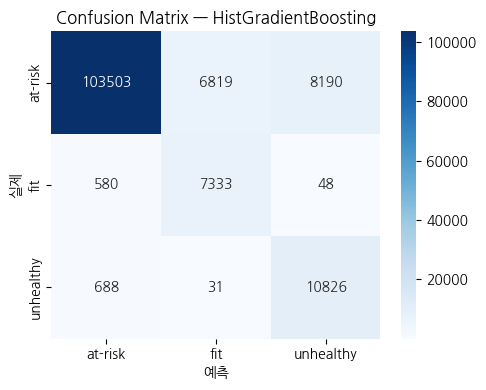

In [15]:
X_all = train_fe[num_final + cat_final]; y_all = le.transform(train_fe[TARGET])
X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=RS)

best_pipe.fit(X_tr, y_tr)
pv = best_pipe.predict(X_val)
print('Validation balanced_accuracy:', round(balanced_accuracy_score(y_val, pv), 4))
print('Validation f1_macro        :', round(f1_score(y_val, pv, average='macro'), 4))
print('\n', classification_report(y_val, pv, target_names=le.classes_))

cm = confusion_matrix(y_val, pv)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('예측'); plt.ylabel('실제'); plt.title(f'Confusion Matrix — {FINAL_MODEL}')
plt.tight_layout(); plt.savefig(RESULT_DIR + 'confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()


In [16]:
# 전체 데이터 재학습 → 제출
t0=time.time(); best_pipe.fit(X_all, y_all); print(f'전체 재학습 {time.time()-t0:.1f}s')
test_pred = le.inverse_transform(best_pipe.predict(test_fe[num_final + cat_final]))
submission = pd.DataFrame({ID: test[ID], TARGET: test_pred})
submission.to_csv(DATA_PATH + 'submission_final.csv', index=False)
print('저장:', DATA_PATH + 'submission_final.csv', submission.shape)
print(submission[TARGET].value_counts()); submission.head()


전체 재학습 145.4s
저장: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/submission_final.csv (295753, 2)
health_condition
at-risk      224432
unhealthy     40891
fit           30430
Name: count, dtype: int64


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


## 11. 변수 중요도 (선택 모델)

정예 변수 중 무엇이 실제로 결정에 쓰였는지. 파생변수(`lifestyle_risk_score`, `*_ord` 등)가 상위면 설계가 통한 것.


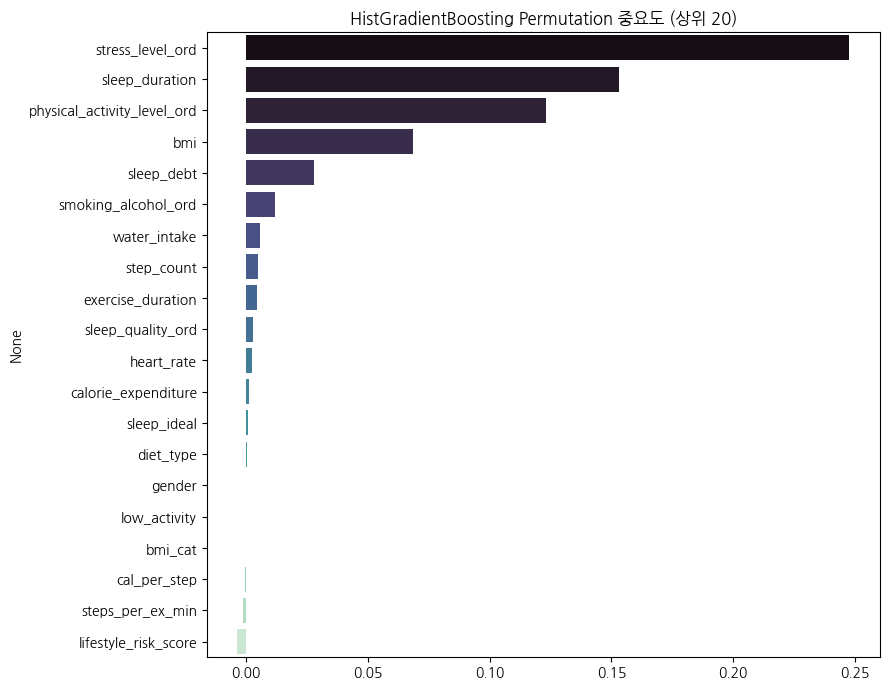

,importance
stress_level_ord,0.2477
sleep_duration,0.1533
physical_activity_level_ord,0.1233
bmi,0.0686
sleep_debt,0.0280
smoking_alcohol_ord,0.0121
water_intake,0.0057
step_count,0.0052
exercise_duration,0.0044
sleep_quality_ord,0.0030


In [17]:
clf = best_pipe.named_steps['clf']
feat_names = best_pipe.named_steps['prep'].get_feature_names_out()
if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(20)
    title = f'{FINAL_MODEL} 변수 중요도 (상위 20)'
else:
    from sklearn.inspection import permutation_importance
    idx = np.random.RandomState(RS).choice(len(X_val), size=min(5000,len(X_val)), replace=False)
    pi = permutation_importance(best_pipe, X_val.iloc[idx], y_val[idx], scoring='balanced_accuracy',
                                n_repeats=5, random_state=RS, n_jobs=-1)
    imp = pd.Series(pi.importances_mean, index=(num_final+cat_final)).sort_values(ascending=False).head(20)
    title = f'{FINAL_MODEL} Permutation 중요도 (상위 20)'
plt.figure(figsize=(9,7)); sns.barplot(x=imp.values, y=imp.index, palette='mako')
plt.title(title); plt.tight_layout()
plt.savefig(RESULT_DIR + 'feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
display(imp.round(4).to_frame('importance'))


## 12. 발표용 정리 및 SCQA

### 저장한 결과 파일

모델 비교와 최종 모델 분석 결과는 `results/` 폴더에 저장한다.

- `model_comparison.csv` — 12개 모델의 성능과 실행시간 비교표
- `model_comparison_scatter.png` — 실행시간과 Balanced Accuracy 비교 그래프
- `confusion_matrix.png` — 최종 모델의 혼동행렬
- `feature_importance.png` — 최종 모델의 주요 변수 중요도 그래프

이 파일들은 발표 자료에 표와 그래프로 바로 활용할 수 있다.

## 모델 선택 과정

발표에서는 다음과 같은 순서로 모델을 선택했다고 설명한다.

1. 학생 건강상태 데이터는 클래스 불균형이 있는 3분류 문제이므로, 한 클래스에 치우친 성능을 방지하기 위해 `balanced_accuracy`를 주요 지표로 사용했다.
2. 선형 모델, 거리 기반 모델, 트리 모델, 부스팅 모델 등 서로 다른 특성을 가진 12개 모델을 동일한 조건에서 비교했다.
3. 성능만 보는 것이 아니라 실행시간과 교차검증 결과의 안정성도 함께 확인하여 후보 모델을 줄였다.
4. 최종 후보 중 성능과 안정성, 실행 효율을 종합적으로 고려해 최종 모델 1개를 선택했다.
5. 선택한 모델의 하이퍼파라미터를 조정한 뒤 전체 학습 데이터로 다시 학습하고, 테스트 데이터 예측 결과를 제출 파일로 저장했다.

> 최종 모델은 단순히 Validation 점수가 가장 높은 모델이 아니라, 성능과 안정성을 함께 고려하여 선택했다.

## SCQA: 서비스 기획 관점

### S — Situation

학생들의 수면, 운동, 식습관, 스트레스와 같은 생활습관 데이터를 설문이나 웨어러블 기기를 통해 수집할 수 있다.

### C — Complication

건강 이상을 증상이 나타난 뒤에 발견하면 생활습관을 개선하거나 상담을 시작하기까지 시간이 늦어질 수 있다. 또한 학교 상담 인력만으로 모든 학생을 지속적으로 관리하기에는 한계가 있다.

### Q — Question

생활습관 데이터를 활용해 건강 위험이 높은 학생을 미리 선별할 수 있을까?

### A — Answer

이번 프로젝트에서는 생활습관 데이터를 바탕으로 학생의 건강상태를 `fit`, `at-risk`, `unhealthy`로 분류하는 모델을 만들었다.

이 모델을 활용하면 위험 가능성이 높은 학생을 먼저 확인하고, 개인별 생활습관에 맞는 코칭이나 상담을 연결할 수 있다.

## 서비스 활용 예시

1. 학생이 설문이나 웨어러블 데이터를 입력한다.
2. 모델이 건강상태와 위험도를 예측한다.
3. 대시보드에서 예측 결과와 주요 위험요인을 보여준다.
4. 위험도가 높은 학생에게 생활습관 개선 알림을 제공한다.
5. 필요하면 상담 선생님이나 보건 담당자와의 상담으로 연결한다.

## 한계와 향후 개선 방향

- 현재 데이터가 합성 데이터일 가능성이 있으므로 실제 서비스에 적용하기 전 임상 데이터 검증이 필요하다.
- 결측치가 많은 경우 예측 결과의 신뢰도가 낮아질 수 있으므로 입력 데이터 수집 품질을 개선해야 한다.
- 현재는 한 시점의 데이터만 사용하므로, 향후에는 시간에 따른 생활습관 변화를 반영하는 시계열 모델을 적용할 수 있다.
- 시계열 데이터를 활용하면 건강상태가 악화되는 변화를 더 일찍 파악할 수 있을 것으로 기대한다.